Cell 1 — Install & Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import plotly.express as px
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (12, 5)

print("✅ Libraries loaded successfully!")

Cell 2 — Load the Datasets

In [4]:
df1 = pd.read_csv("/content/Unemployment in India.csv")
df2 = pd.read_csv("/content/Unemployment_Rate_upto_11_2020.csv")

print("📁 Dataset 1 Shape:", df1.shape)
print("📁 Dataset 2 Shape:", df2.shape)
display(df1.head(3))
display(df2.head(3))

📁 Dataset 1 Shape: (768, 7)
📁 Dataset 2 Shape: (267, 9)


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74


Cell 3 — Data Cleaning

In [5]:
#Clean column names
df1.columns = df1.columns.str.strip()
df2.columns = df2.columns.str.strip()

# Rename columns for easier use
rename_map = {
    'Estimated Unemployment Rate (%)': 'Unemployment_Rate',
    'Estimated Employed': 'Employed',
    'Estimated Labour Participation Rate (%)': 'Labour_Participation_Rate'
}
df1.rename(columns=rename_map, inplace=True)
df2.rename(columns=rename_map, inplace=True)

# Strip whitespace from string columns
df1['Region'] = df1['Region'].str.strip()
df1['Area']   = df1['Area'].str.strip()
df2['Region'] = df2['Region'].str.strip()

# Parse Date column
df1['Date'] = pd.to_datetime(df1['Date'].str.strip(), format='%d-%m-%Y')
df2['Date'] = pd.to_datetime(df2['Date'].str.strip(), format='%d-%m-%Y')

# Extract Month & Year
df1['Month'] = df1['Date'].dt.month_name()
df1['Year']  = df1['Date'].dt.year
df2['Month'] = df2['Date'].dt.month_name()
df2['Year']  = df2['Date'].dt.year

# Handle missing values in df1
print("🔎 Missing values BEFORE cleaning:\n", df1.isnull().sum())
df1.dropna(inplace=True)
print("\n✅ Missing values AFTER cleaning:\n", df1.isnull().sum())

🔎 Missing values BEFORE cleaning:
 Region                       28
Date                         28
Frequency                    28
Unemployment_Rate            28
Employed                     28
Labour_Participation_Rate    28
Area                         28
Month                        28
Year                         28
dtype: int64

✅ Missing values AFTER cleaning:
 Region                       0
Date                         0
Frequency                    0
Unemployment_Rate            0
Employed                     0
Labour_Participation_Rate    0
Area                         0
Month                        0
Year                         0
dtype: int64


Cell 4 — Exploratory Data Analysis (EDA)

In [6]:
print("=" * 50)
print("📊 DATASET 1 — Statistical Summary")
print("=" * 50)
display(df1.describe())

print("\n" + "=" * 50)
print("📊 DATASET 2 — Statistical Summary")
print("=" * 50)
display(df2.describe())

print("\n📌 Unique Regions in DF1:", df1['Region'].nunique())
print("📌 Date Range DF1:", df1['Date'].min(), "→", df1['Date'].max())
print("📌 Date Range DF2:", df2['Date'].min(), "→", df2['Date'].max())

📊 DATASET 1 — Statistical Summary


,Date,Unemployment_Rate,Employed,Labour_Participation_Rate,Year
count,740,740.000000,7.400000e+02,740.000000,740.000000
mean,2019-12-12 18:36:58.378378496,11.787946,7.204460e+06,42.630122,2019.418919
min,2019-05-31 00:00:00,0.000000,4.942000e+04,13.330000,2019.000000
25%,2019-08-31 00:00:00,4.657500,1.190404e+06,38.062500,2019.000000
50%,2019-11-30 00:00:00,8.350000,4.744178e+06,41.160000,2019.000000
75%,2020-03-31 00:00:00,15.887500,1.127549e+07,45.505000,2020.000000
max,2020-06-30 00:00:00,76.740000,4.577751e+07,72.570000,2020.000000
std,NaN,10.721298,8.087988e+06,8.111094,0.493716



📊 DATASET 2 — Statistical Summary


,Date,Unemployment_Rate,Employed,Labour_Participation_Rate,longitude,latitude,Year
count,267,267.000000,2.670000e+02,267.000000,267.000000,267.000000,267.0
mean,2020-06-16 09:15:30.337078528,12.236929,1.396211e+07,41.681573,22.826048,80.532425,2020.0
min,2020-01-31 00:00:00,0.500000,1.175420e+05,16.770000,10.850500,71.192400,2020.0
25%,2020-03-31 00:00:00,4.845000,2.838930e+06,37.265000,18.112400,76.085600,2020.0
50%,2020-06-30 00:00:00,9.650000,9.732417e+06,40.390000,23.610200,79.019300,2020.0
75%,2020-08-31 00:00:00,16.755000,2.187869e+07,44.055000,27.278400,85.279900,2020.0
max,2020-10-31 00:00:00,75.850000,5.943376e+07,69.690000,33.778200,92.937600,2020.0
std,NaN,10.803283,1.336632e+07,7.845419,6.270731,5.831738,0.0



📌 Unique Regions in DF1: 28
📌 Date Range DF1: 2019-05-31 00:00:00 → 2020-06-30 00:00:00
📌 Date Range DF2: 2020-01-31 00:00:00 → 2020-10-31 00:00:00


Cell 5 — Overall Unemployment Trend Over Time

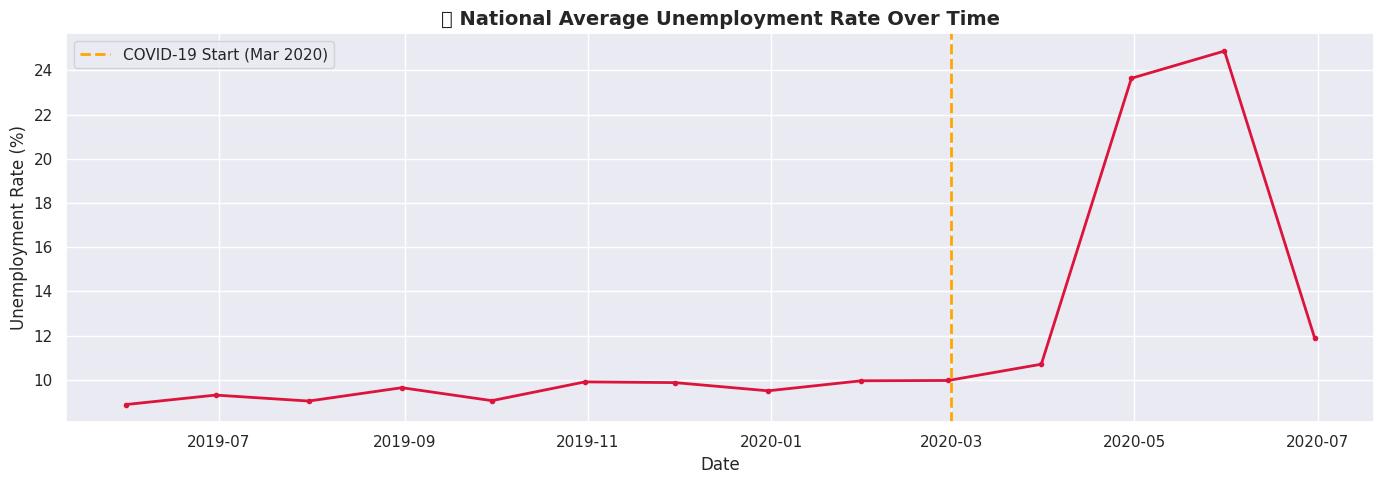

In [7]:
monthly_avg = df1.groupby('Date')['Unemployment_Rate'].mean().reset_index()

plt.figure(figsize=(14, 5))
plt.plot(monthly_avg['Date'], monthly_avg['Unemployment_Rate'],
         color='crimson', linewidth=2, marker='o', markersize=3)
plt.axvline(pd.to_datetime('2020-03-01'), color='orange',
            linestyle='--', linewidth=2, label='COVID-19 Start (Mar 2020)')
plt.title('📈 National Average Unemployment Rate Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.legend()
plt.tight_layout()
plt.show()

 Cell 6 — COVID-19 Impact Analysis

📉 Avg Unemployment BEFORE COVID  : 9.23%
📈 Avg Unemployment DURING COVID  : 13.01%
🔴 PEAK Unemployment Rate         : 23.24% on May 2020


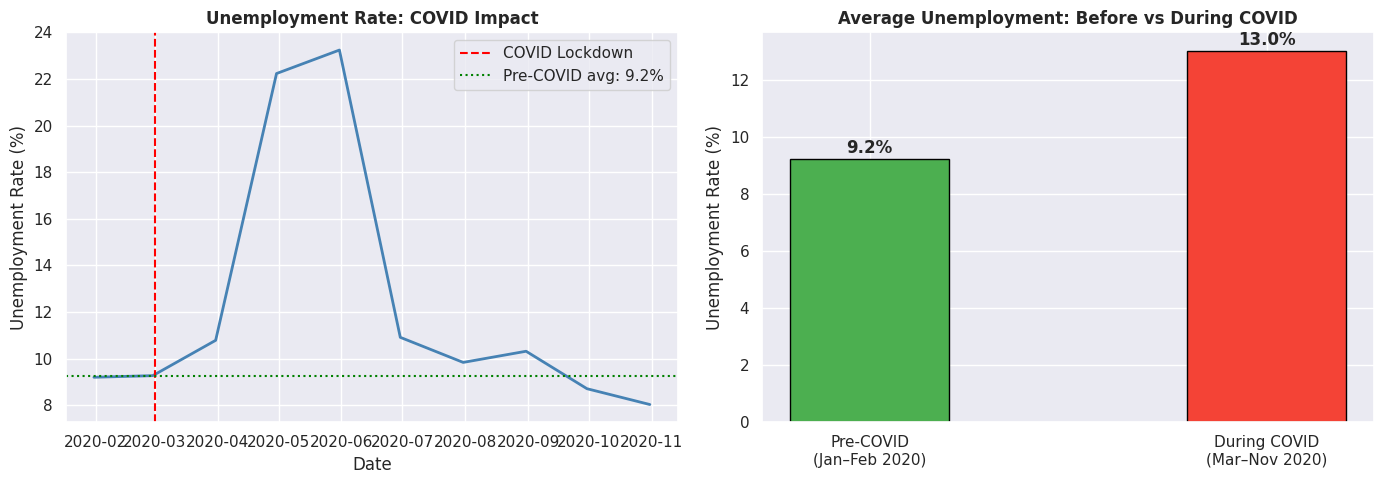

In [8]:
monthly_df2 = df2.groupby('Date')['Unemployment_Rate'].mean().reset_index()

pre_covid  = monthly_df2[monthly_df2['Date'] < '2020-03-01']['Unemployment_Rate'].mean()
post_covid = monthly_df2[monthly_df2['Date'] >= '2020-03-01']['Unemployment_Rate'].mean()
peak_covid = monthly_df2['Unemployment_Rate'].max()
peak_date  = monthly_df2.loc[monthly_df2['Unemployment_Rate'].idxmax(), 'Date']

print(f"📉 Avg Unemployment BEFORE COVID  : {pre_covid:.2f}%")
print(f"📈 Avg Unemployment DURING COVID  : {post_covid:.2f}%")
print(f"🔴 PEAK Unemployment Rate         : {peak_covid:.2f}% on {peak_date.strftime('%B %Y')}")

# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Line plot
axes[0].plot(monthly_df2['Date'], monthly_df2['Unemployment_Rate'],
             color='steelblue', linewidth=2)
axes[0].axvline(pd.to_datetime('2020-03-01'), color='red',
                linestyle='--', label='COVID Lockdown')
axes[0].axhline(pre_covid, color='green', linestyle=':', label=f'Pre-COVID avg: {pre_covid:.1f}%')
axes[0].set_title('Unemployment Rate: COVID Impact', fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Unemployment Rate (%)')
axes[0].legend()

# Bar comparison
labels = ['Pre-COVID\n(Jan–Feb 2020)', 'During COVID\n(Mar–Nov 2020)']
values = [pre_covid, post_covid]
colors = ['#4CAF50', '#F44336']
axes[1].bar(labels, values, color=colors, edgecolor='black', width=0.4)
axes[1].set_title('Average Unemployment: Before vs During COVID', fontweight='bold')
axes[1].set_ylabel('Unemployment Rate (%)')
for i, v in enumerate(values):
    axes[1].text(i, v + 0.2, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

Cell 7 — Regional Analysis (Top & Bottom States)

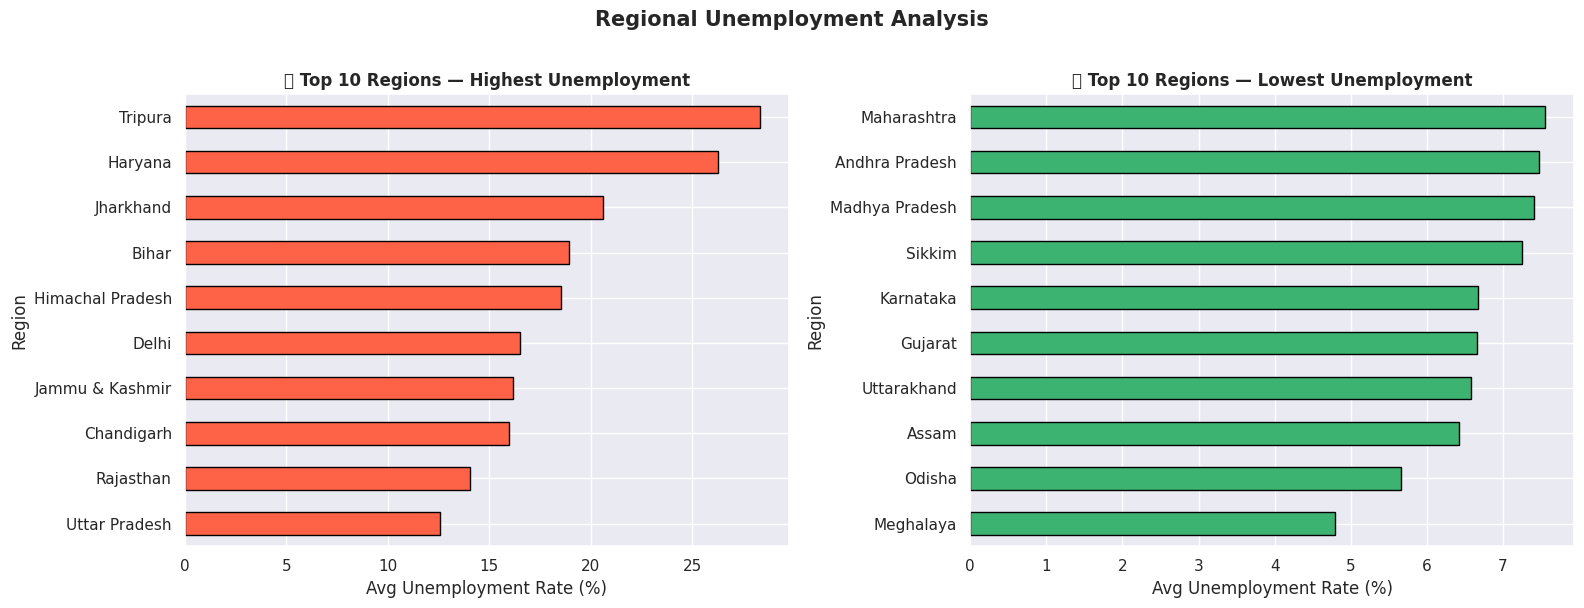

In [9]:
region_avg = df1.groupby('Region')['Unemployment_Rate'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))


region_avg.head(10).plot(kind='barh', ax=axes[0], color='tomato', edgecolor='black')
axes[0].set_title('🔴 Top 10 Regions — Highest Unemployment', fontweight='bold')
axes[0].set_xlabel('Avg Unemployment Rate (%)')
axes[0].invert_yaxis()

# Top 10 lowest unemployment
region_avg.tail(10).plot(kind='barh', ax=axes[1], color='mediumseagreen', edgecolor='black')
axes[1].set_title('🟢 Top 10 Regions — Lowest Unemployment', fontweight='bold')
axes[1].set_xlabel('Avg Unemployment Rate (%)')
axes[1].invert_yaxis()

plt.suptitle('Regional Unemployment Analysis', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Cell 8 — Rural vs Urban Analysis

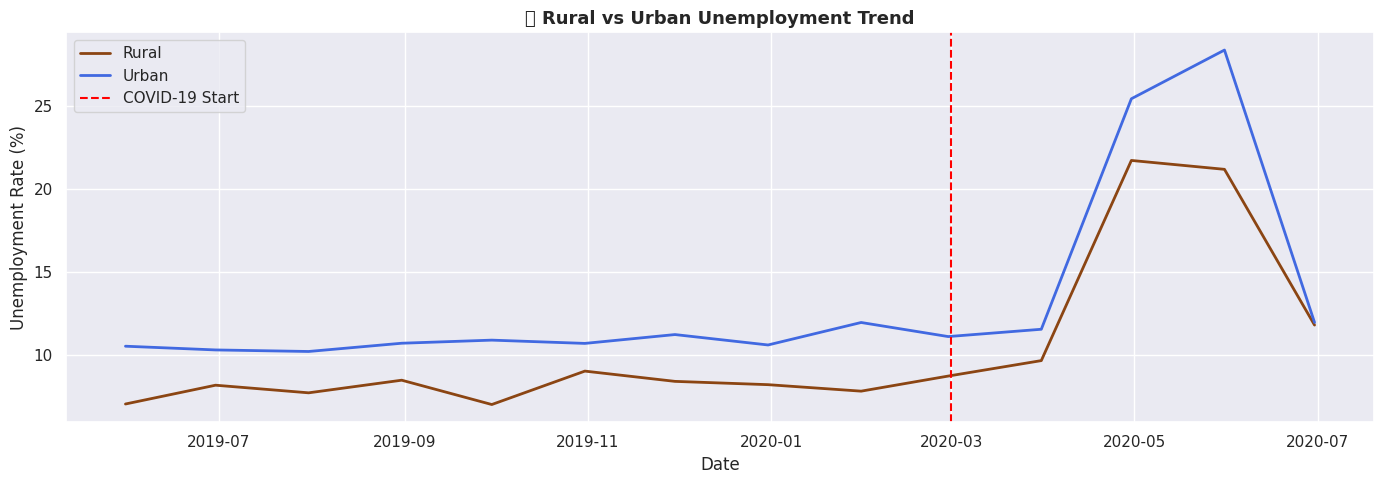

       count   mean    std  min   25%   50%    75%    max
Area                                                     
Rural  359.0  10.32  10.04  0.0  3.79  6.76  13.76  74.51
Urban  381.0  13.17  11.17  0.0  5.82  9.97  18.04  76.74


In [10]:
area_monthly = df1.groupby(['Date', 'Area'])['Unemployment_Rate'].mean().reset_index()
rural  = area_monthly[area_monthly['Area'] == 'Rural']
urban  = area_monthly[area_monthly['Area'] == 'Urban']

plt.figure(figsize=(14, 5))
plt.plot(rural['Date'], rural['Unemployment_Rate'],
         label='Rural', color='saddlebrown', linewidth=2)
plt.plot(urban['Date'], urban['Unemployment_Rate'],
         label='Urban', color='royalblue', linewidth=2)
plt.axvline(pd.to_datetime('2020-03-01'), color='red',
            linestyle='--', linewidth=1.5, label='COVID-19 Start')
plt.title('🏘️ Rural vs Urban Unemployment Trend', fontsize=13, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.legend()
plt.tight_layout()
plt.show()

print(df1.groupby('Area')['Unemployment_Rate'].describe().round(2))

Cell 9 — Seasonal Trends

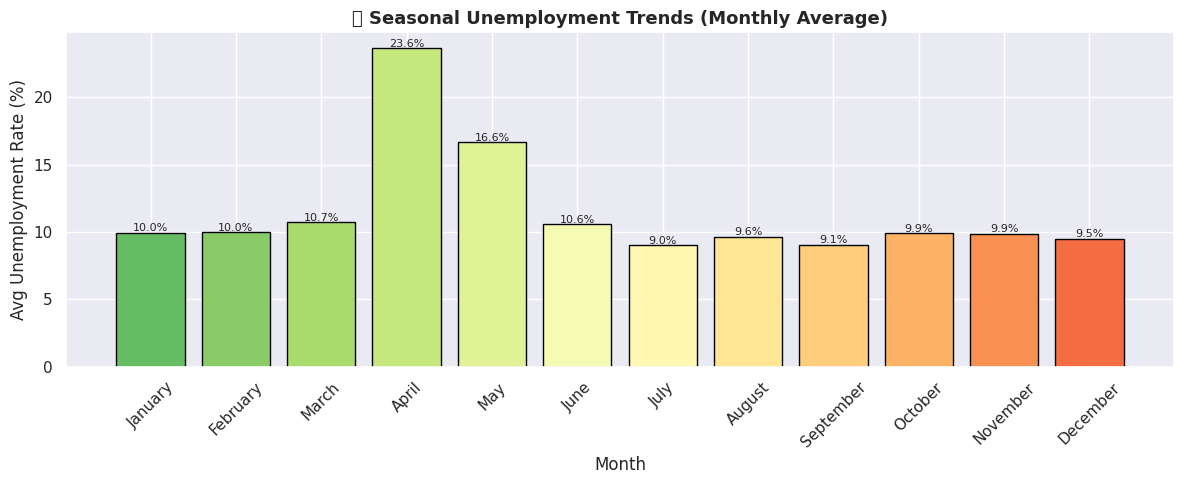

In [11]:
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

seasonal = df1.groupby('Month')['Unemployment_Rate'].mean().reindex(month_order)

plt.figure(figsize=(12, 5))
bars = plt.bar(seasonal.index, seasonal.values,
               color=plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, 12)),
               edgecolor='black')
plt.title('📅 Seasonal Unemployment Trends (Monthly Average)', fontsize=13, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Avg Unemployment Rate (%)')
plt.xticks(rotation=45)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.1,
             f'{bar.get_height():.1f}%',
             ha='center', fontsize=8)
plt.tight_layout()
plt.show()

Cell 10 — Heatmap: Region × Month

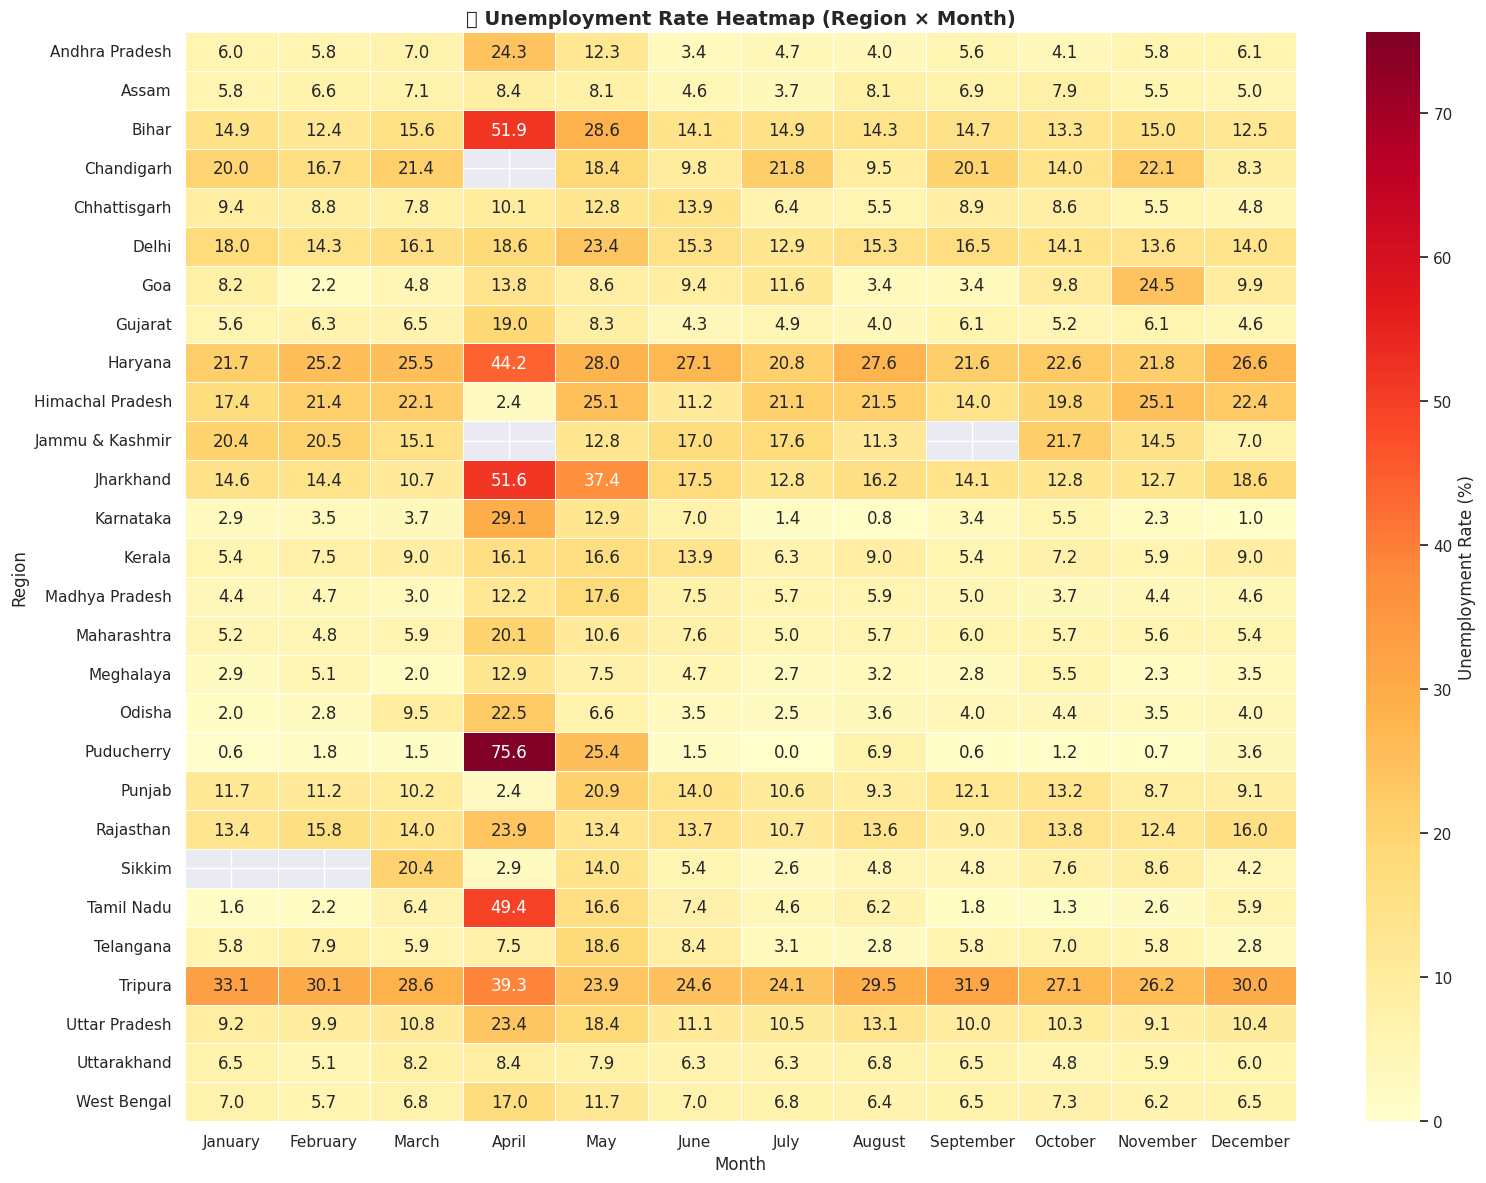

In [12]:
pivot = df1.pivot_table(values='Unemployment_Rate',
                         index='Region', columns='Month',
                         aggfunc='mean')[month_order]

plt.figure(figsize=(16, 12))
sns.heatmap(pivot, cmap='YlOrRd', annot=True, fmt='.1f',
            linewidths=0.4, cbar_kws={'label': 'Unemployment Rate (%)'})
plt.title('🗺️ Unemployment Rate Heatmap (Region × Month)', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Region')
plt.tight_layout()
plt.show()

Cell 11 — Interactive Map (Plotly)


In [13]:
region_geo = df2.groupby(['Region', 'latitude', 'longitude'])['Unemployment_Rate'].mean().reset_index()

fig = px.scatter_mapbox(
    region_geo,
    lat='latitude', lon='longitude',
    size='Unemployment_Rate',
    color='Unemployment_Rate',
    color_continuous_scale='Reds',
    hover_name='Region',
    hover_data={'Unemployment_Rate': ':.2f'},
    zoom=4,
    mapbox_style='carto-positron',
    title='🗺️ Average Unemployment Rate by Region (2020)',
    size_max=30
)
fig.update_layout(margin={"r":0,"t":40,"l":0,"b":0})
fig.show()

Cell 12 — Key Insights & Policy Summary

In [14]:
print("=" * 60)
print("       📋 KEY FINDINGS — UNEMPLOYMENT ANALYSIS")
print("=" * 60)

print(f"""
🔍 DATASET OVERVIEW:
   • Dataset 1: {df1.shape[0]} records | {df1['Region'].nunique()} states
   • Date Range: {df1['Date'].min().strftime('%b %Y')} → {df1['Date'].max().strftime('%b %Y')}

📌 NATIONAL STATISTICS:
   • Average Unemployment Rate  : {df1['Unemployment_Rate'].mean():.2f}%
   • Min Rate                   : {df1['Unemployment_Rate'].min():.2f}%
   • Max Rate                   : {df1['Unemployment_Rate'].max():.2f}%

🦠 COVID-19 IMPACT:
   • Pre-COVID avg  : {pre_covid:.2f}%
   • During-COVID avg: {post_covid:.2f}%
   • Increase        : +{post_covid - pre_covid:.2f}%
   • Peak            : {peak_covid:.2f}% ({peak_date.strftime('%B %Y')})

🏘️ RURAL vs URBAN:
   • Rural avg: {df1[df1['Area']=='Rural']['Unemployment_Rate'].mean():.2f}%
   • Urban avg: {df1[df1['Area']=='Urban']['Unemployment_Rate'].mean():.2f}%

🔴 MOST AFFECTED REGION  : {region_avg.idxmax()}
🟢 LEAST AFFECTED REGION : {region_avg.idxmin()}

💡 POLICY RECOMMENDATIONS:
   1. Urban areas need stronger job-retention schemes during crises
   2. COVID showed need for social safety nets (unemployment benefits)
   3. High-unemployment states need targeted skill development programs
   4. Seasonal spikes (Mar–May) suggest agricultural dependency issues
""")
print("=" * 60)

       📋 KEY FINDINGS — UNEMPLOYMENT ANALYSIS

🔍 DATASET OVERVIEW:
   • Dataset 1: 740 records | 28 states
   • Date Range: May 2019 → Jun 2020

📌 NATIONAL STATISTICS:
   • Average Unemployment Rate  : 11.79%
   • Min Rate                   : 0.00%
   • Max Rate                   : 76.74%

🦠 COVID-19 IMPACT:
   • Pre-COVID avg  : 9.23%
   • During-COVID avg: 13.01%
   • Increase        : +3.78% 
   • Peak            : 23.24% (May 2020)

🏘️ RURAL vs URBAN:
   • Rural avg: 10.32%
   • Urban avg: 13.17%

🔴 MOST AFFECTED REGION  : Tripura
🟢 LEAST AFFECTED REGION : Meghalaya

💡 POLICY RECOMMENDATIONS:
   1. Urban areas need stronger job-retention schemes during crises
   2. COVID showed need for social safety nets (unemployment benefits)
   3. High-unemployment states need targeted skill development programs
   4. Seasonal spikes (Mar–May) suggest agricultural dependency issues

